In [1]:
import pandas as pd

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path('/Users/jmi/기타/2023_연간자료_등록기반_20260311_01354.csv')
df = pd.read_csv(data_path, encoding='cp949')
print(df.shape)


In [3]:
df.head(3)

,조사기준연도,일반_대표자_성별코드,대표자연령대코드,일반_소재지_운영장소코드,일반_합계종사자수,일반_합계_남자종사자수,일반_합계_여자종사자수,일반_대표자종사자수,일반_대표자_남자종사자수,일반_대표자_여자종사자수,...,사업전환_운영계획코드,사업전환_운영계획_소유권승계계획여부,사업전환_노후준비1해당여부,사업전환_노후준비2해당여부,사업전환_노후준비3해당여부,사업전환_노후준비4해당여부,사업전환_노후준비5해당여부,사업전환_노후준비6해당여부,사업체수가중값,행정구역시도코드
0,2023,1,10,1,1,1,0,1,1,0,...,2,NaN,NaN,1.0,NaN,NaN,NaN,NaN,17.666667,29
1,2023,1,10,1,2,2,0,1,1,0,...,1,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1240.719101,31
2,2023,1,10,1,3,2,1,1,1,0,...,1,2.0,1.0,NaN,NaN,NaN,NaN,NaN,14.513514,38


# 피처 엔지니어링

In [4]:
df["창업_어려움정도_자금조달코드"].unique() # nan값은 모두 0을 표현한 것임을 파악

array([nan,  4.,  3.,  5.,  2.,  1.])

In [5]:
 # 결측치 0으로 채움
df = df.fillna(0)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.shape

(40000, 156)

In [8]:
rename_dict = {

# 경영 운영활동
"경영_운영활동코드1": "경영_운영활동_차별화된제품개발",
"경영_운영활동코드2": "경영_운영활동_제품서비스품질향상",
"경영_운영활동코드3": "경영_운영활동_판로개척",
"경영_운영활동코드4": "경영_운영활동_해외진출",
"경영_운영활동코드5": "경영_운영활동_브랜드마케팅",
"경영_운영활동코드6": "경영_운영활동_제품인증",
"경영_운영활동코드7": "경영_운영활동_비즈니스모델확장",
"경영_운영활동코드8": "경영_운영활동_투자유치",
"경영_운영활동코드9": "경영_운영활동_활동상황없음",

# 디지털 대응
"경영_운영활동_디지털대응1코드": "경영_운영활동_스마트주문결제",
"경영_운영활동_디지털대응2코드": "경영_운영활동_매장관리",
"경영_운영활동_디지털대응3코드": "경영_운영활동_경영관리소프트웨어",
"경영_운영활동_디지털대응4코드": "경영_운영활동_자동화",
"경영_운영활동_디지털대응5코드": "경영_운영활동_디지털광고",
"경영_운영활동_디지털대응6코드": "경영_운영활동_온라인판로",
"경영_운영활동_디지털대응7코드": "경영_운영활동_기타",
"경영_운영활동_디지털대응8코드": "경영_운영활동_활동사항없음",

# 경영 애로사항
"경영_애로사항1코드": "경영_애로사항_상권쇠퇴",
"경영_애로사항2코드": "경영_애로사항_동일업종경쟁심화",
"경영_애로사항3코드": "경영_애로사항_원재료비재료매입비",
"경영_애로사항4코드": "경영_애로사항_최저임금영향",
"경영_애로사항5코드": "경영_애로사항_보증금월세",
"경영_애로사항6코드": "경영_애로사항_부채상환",
"경영_애로사항7코드": "경영_애로사항_인력관리",
"경영_애로사항8코드": "경영_애로사항_판로개척및운영",
"경영_애로사항9코드": "경영_애로사항_디지털기술도입",
"경영_애로사항10코드": "경영_애로사항_기타",

# 정부지원정책
"정부지원정책_추진정책1코드": "정부지원정책_자금지원",
"정부지원정책_추진정책2코드": "정부지원정책_인력지원",
"정부지원정책_추진정책3코드": "정부지원정책_세제지원",
"정부지원정책_추진정책4코드": "정부지원정책_기술지원",
"정부지원정책_추진정책5코드": "정부지원정책_판로지원",
"정부지원정책_추진정책6코드": "정부지원정책_디지털도입전환",
"정부지원정책_추진정책7코드": "정부지원정책_퇴로지원",
"정부지원정책_추진정책8코드": "정부지원정책_기타"

}

df = df.rename(columns=rename_dict)

In [9]:
drop_cols = [
    
#재난지원 관련 정부지원정책 칼럼 삭제
"정부지원정책_재난지원1코드",
"정부지원정책_재난지원2코드",
"정부지원정책_재난지원3코드",
"정부지원정책_재난지원4코드",
"정부지원정책_재난지원5코드",
"정부지원정책_재난지원6코드",
"정부지원정책_재난지원7코드",
"정부지원정책_재난지원8코드",

#노후준비 여부 컬럼 삭제
"사업전환_노후준비1해당여부",                
"사업전환_노후준비2해당여부",               
"사업전환_노후준비3해당여부",             
"사업전환_노후준비4해당여부",               
"사업전환_노후준비5해당여부",                
"사업전환_노후준비6해당여부",

# 세부 종사자 수 컬럼 삭제
'일반_합계_남자종사자수',
'일반_합계_여자종사자수',
'일반_대표자종사자수',
'일반_대표자_남자종사자수',
'일반_대표자_여자종사자수',
'일반_근로계약기간_1년이상_종사자수',
'일반_근로계약기간_1년이상_남자종사자수',
'일반_근로계약기간_1년이상_여자종사자수',
'일반_근로계약기간_3개월이상1년미만_종사자수',
'일반_근로계약기간_3개월이상1년미만_남자종사자수',
'일반_근로계약기간_3개월이상1년미만_여자종사자수',
'일반_근로계약기간_3개월미만_종사자수',
'일반_근로계약기간_3개월미만_남자종사자수',
'일반_근로계약기간_3개월미만_여자종사자수',
'일반_무급가족종사자수',
'일반_무급가족_남자종사자수',
'일반_무급가족_여자종사자수',
'일반_기타근로자종사자수',
'일반_기타근로자_남자종사자수',
'일반_기타근로자_여자종사자수',
'일반_소재지_운영장소코드'
]

df = df.drop(columns=drop_cols)

In [10]:
df.shape

(40000, 121)

In [11]:
# 전체 컬럼 보기
print(df.columns.tolist())

['조사기준연도', '일반_대표자_성별코드', '대표자연령대코드', '일반_합계종사자수', '일반_무급가족종사자_부부여부', '일반_무급가족종사자_부모여부', '일반_무급가족종사자_자녀여부', '일반_무급가족종사자_친인척여부', '일반_사업자형태코드', '산업대분류코드', '산업중분류코드', '일반_프랜차이즈가맹점여부', '일반_창업형태코드', '일반_창업인수승계_연도', '일반_창업인수승계_월', '일반_사업장이전_경험여부', '일반_사업장이전_사유코드', '일반_현사업체_직전종사상지위항목코드', '일반_창업횟수', '창업_동기코드', '창업_준비기간_창업_준비기간_년수', '창업_준비기간_창업_준비기간_월수', '창업_준비활동중요성_사업계획서작성코드', '창업_준비활동중요성_시장조사코드', '창업_준비활동중요성_동종업종종사경험코드', '창업_준비활동중요성_창업교육코드', '창업_준비활동_사업계획서작성여부', '창업_준비활동_시장조사여부', '창업_준비활동_동종업종종사경험여부', '창업_준비활동_창업교육여부', '창업_어려움정도_입지선정코드', '창업_어려움정도_업종선택코드', '창업_어려움정도_자금조달코드', '창업_어려움정도_기술확보코드', '창업_어려움정도_인력확보코드', '창업_어려움정도_행정절차코드', '창업_어려움정도_경영방법코드', '창업_비용_총창업비용', '창업_비용_본인부담금액', '경영_영업기간_하루평균시간수', '경영_영업기간_월평균일수', '경영_영업기간_년간월수', '경영_점유형태코드', '경영_점유형태_임차형태코드', '경영_점유형태_보증금액', '경영_점유형태_월세금액', '경영_점유형태_일정비율지급금액', '경영_사업장면적', '경영_운영활동_차별화된제품개발', '경영_운영활동_제품서비스품질향상', '경영_운영활동_판로개척', '경영_운영활동_해외진출', '경영_운영활동_브랜드마케팅', '경영_운영활동_제품인증', '경영_운영활동_비즈니스모델확장', '경영_운영활동_투자유치', '경영_운영활동_활동상황없음', '경영_운영평가_사

In [12]:
df["사업전환_운영계획코드"].value_counts()

사업전환_운영계획코드
1    37565
4     1252
2      645
3      538
Name: count, dtype: int64

In [13]:
df["사업지속여부"] = df["사업전환_운영계획코드"].map({
    1: 0, # 계속 운영
    2: 1, # 사업전환(업종전환, 재창업)
    3: 1, # 폐업 후 임금 근로자 희망
    4: 1 # 폐업 및 은퇴
})
# df = df.drop(columns=["사업전환_운영계획코드"])

In [14]:
df["사업지속여부"].value_counts()

사업지속여부
0    37565
1     2435
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [16]:
industry_major_map = {
"C": "제조업",
"F": "건설업",
"G": "도소매업",
"I": "숙박음식점업",
"J": "정보통신업",
"L": "부동산업",
"M": "전문과학기술업",
"N": "사업시설지원업",
"P": "교육서비스업",
"R": "예술스포츠여가업",
"S": "수리기타서비스업"
}

df["산업대분류"] = df["산업대분류코드"].map(industry_major_map)

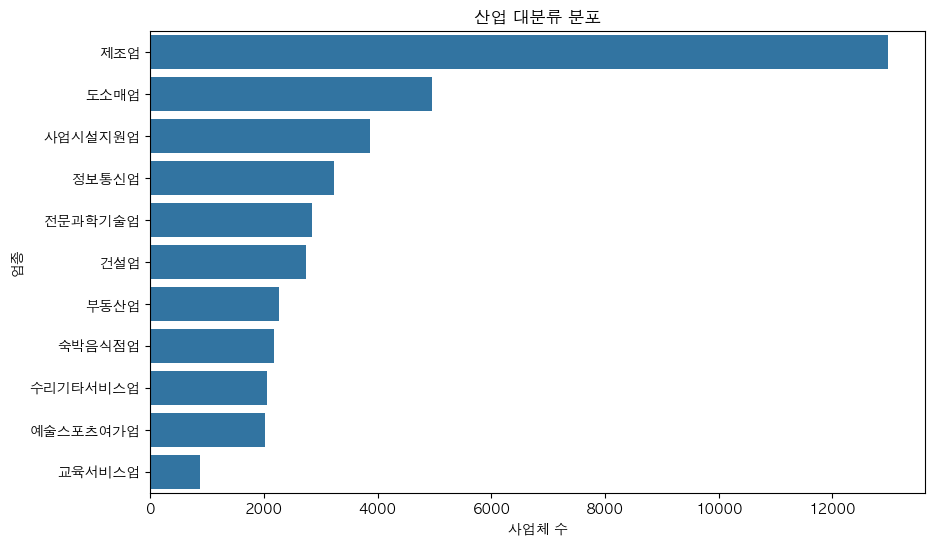

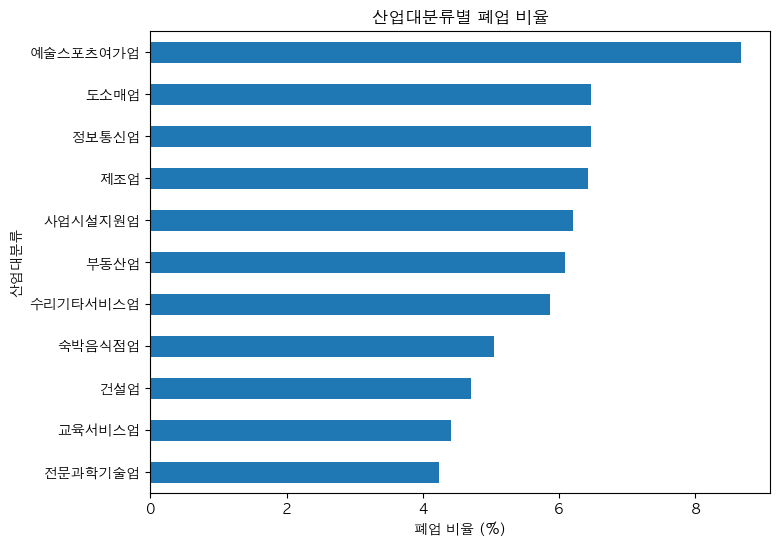

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    y="산업대분류",
    data=df,
    order=df["산업대분류"].value_counts().index
)

plt.title("산업 대분류 분포")
plt.xlabel("사업체 수")
plt.ylabel("업종")

plt.show()


industry_exit_rate = df.groupby("산업대분류")["사업지속여부"].mean() * 100
industry_exit_rate.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.xlabel("폐업 비율 (%)")
plt.title("산업대분류별 폐업 비율")

plt.show()

In [18]:
industry_mid_map = {
1: "농업",
2: "임업",
3: "어업",
5: "석탄·원유 및 천연가스 광업",
6: "금속 광업",
7: "비금속광물 광업",
8: "광업 지원 서비스업",

10: "식료품 제조업",
11: "음료 제조업",
12: "담배 제조업",
13: "섬유제품 제조업",
14: "의복 및 모피제품 제조업",
15: "가죽·가방·신발 제조업",
16: "목재 및 나무제품 제조업",
17: "펄프·종이제품 제조업",
18: "인쇄 및 기록매체 복제업",
19: "코크스·석유정제품 제조업",
20: "화학제품 제조업",
21: "의약품 제조업",
22: "고무·플라스틱 제조업",
23: "비금속 광물제품 제조업",
24: "1차 금속 제조업",
25: "금속가공제품 제조업",
26: "전자부품·컴퓨터·통신장비 제조업",
27: "의료·정밀기기 제조업",
28: "전기장비 제조업",
29: "기계 및 장비 제조업",
30: "자동차 및 트레일러 제조업",
31: "기타 운송장비 제조업",
32: "가구 제조업",
33: "기타 제품 제조업",
34: "산업용 기계 수리업",

35: "전기·가스 공급업",
36: "수도업",
37: "하수 및 폐수 처리업",
38: "폐기물 처리업",
39: "환경 정화업",

41: "종합 건설업",
42: "전문 공사업",

45: "자동차 및 부품 판매업",
46: "도매 및 상품 중개업",
47: "소매업",

49: "육상운송업",
50: "수상운송업",
51: "항공운송업",
52: "창고 및 운송 서비스업",

55: "숙박업",
56: "음식점 및 주점업",

58: "출판업",
59: "영상·오디오 제작업",
60: "방송업",
61: "우편 및 통신업",
62: "컴퓨터 프로그래밍업",
63: "정보서비스업",

64: "금융업",
65: "보험 및 연금업",
66: "금융 관련 서비스업",

68: "부동산업",

70: "연구개발업",
71: "전문 서비스업",
72: "건축·엔지니어링 서비스업",
73: "기타 과학기술 서비스업",

74: "사업시설 관리업",
75: "사업지원 서비스업",
76: "임대업",

84: "공공행정",

85: "교육 서비스업",

86: "보건업",
87: "사회복지 서비스업",

90: "예술 및 창작 서비스업",
91: "스포츠 및 오락 서비스업",

94: "협회 및 단체",
95: "개인 및 소비용품 수리업",
96: "기타 개인 서비스업",

97: "가구 내 고용활동",
98: "자가소비 생산활동",
99: "국제 및 외국기관"
}

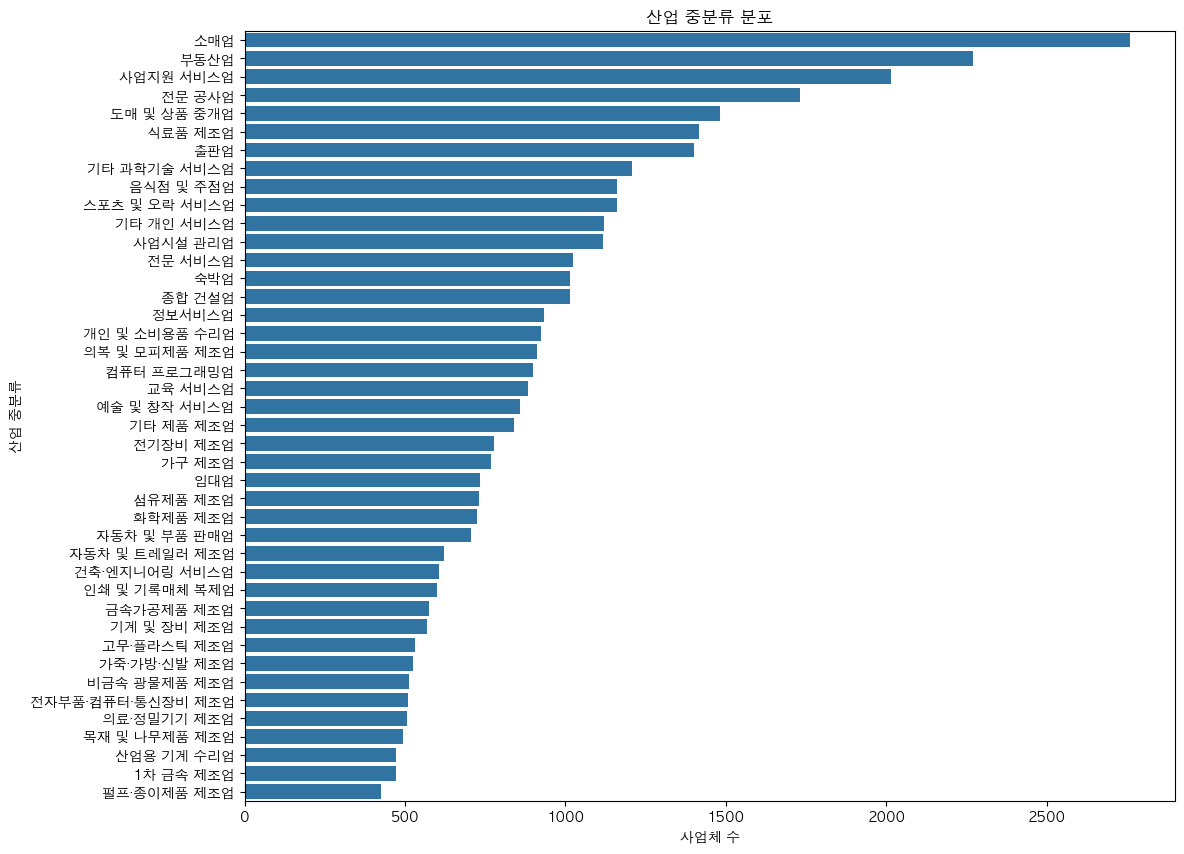

In [19]:
df["산업중분류"] = df["산업중분류코드"].map(industry_mid_map)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.countplot(
    y="산업중분류",
    data=df,
    order=df["산업중분류"].value_counts().index
)

plt.title("산업 중분류 분포")
plt.xlabel("사업체 수")
plt.ylabel("산업 중분류")

plt.show()

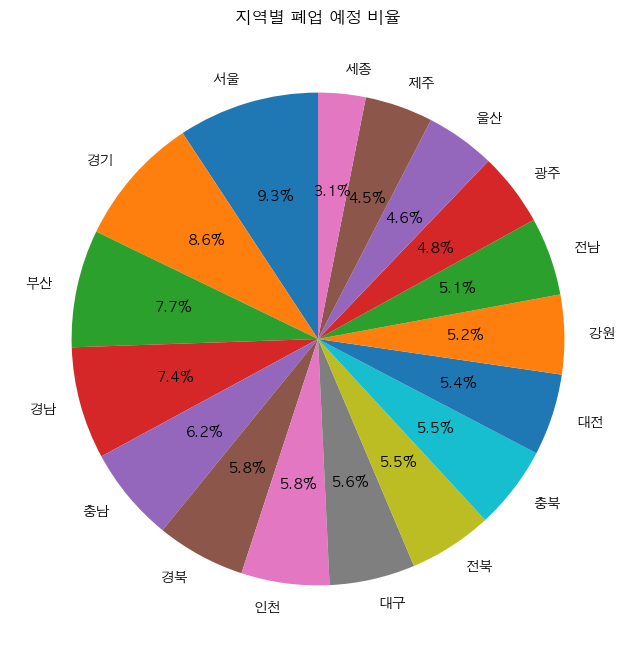

In [20]:
# 시도 코드 매핑
region_map = {
11: "서울",
21: "부산",
22: "대구",
23: "인천",
24: "광주",
25: "대전",
26: "울산",
29: "세종",
31: "경기",
32: "강원",
33: "충북",
34: "충남",
35: "전북",
36: "전남",
37: "경북",
38: "경남",
39: "제주"
}
df["시도"] = df["행정구역시도코드"].map(region_map)

#사업지속여부 x 데이터만 추출
df_continue = df[df["사업지속여부"] == 0]
# 시도별 비율 계산
region_ratio = df_continue["시도"].value_counts(normalize=True) * 100
# 원그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    region_ratio,
    labels=region_ratio.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("지역별 폐업 예정 비율")

plt.show()

In [21]:
# 전체 컬럼 보기
print(df.columns.tolist())

['조사기준연도', '일반_대표자_성별코드', '대표자연령대코드', '일반_합계종사자수', '일반_무급가족종사자_부부여부', '일반_무급가족종사자_부모여부', '일반_무급가족종사자_자녀여부', '일반_무급가족종사자_친인척여부', '일반_사업자형태코드', '산업대분류코드', '산업중분류코드', '일반_프랜차이즈가맹점여부', '일반_창업형태코드', '일반_창업인수승계_연도', '일반_창업인수승계_월', '일반_사업장이전_경험여부', '일반_사업장이전_사유코드', '일반_현사업체_직전종사상지위항목코드', '일반_창업횟수', '창업_동기코드', '창업_준비기간_창업_준비기간_년수', '창업_준비기간_창업_준비기간_월수', '창업_준비활동중요성_사업계획서작성코드', '창업_준비활동중요성_시장조사코드', '창업_준비활동중요성_동종업종종사경험코드', '창업_준비활동중요성_창업교육코드', '창업_준비활동_사업계획서작성여부', '창업_준비활동_시장조사여부', '창업_준비활동_동종업종종사경험여부', '창업_준비활동_창업교육여부', '창업_어려움정도_입지선정코드', '창업_어려움정도_업종선택코드', '창업_어려움정도_자금조달코드', '창업_어려움정도_기술확보코드', '창업_어려움정도_인력확보코드', '창업_어려움정도_행정절차코드', '창업_어려움정도_경영방법코드', '창업_비용_총창업비용', '창업_비용_본인부담금액', '경영_영업기간_하루평균시간수', '경영_영업기간_월평균일수', '경영_영업기간_년간월수', '경영_점유형태코드', '경영_점유형태_임차형태코드', '경영_점유형태_보증금액', '경영_점유형태_월세금액', '경영_점유형태_일정비율지급금액', '경영_사업장면적', '경영_운영활동_차별화된제품개발', '경영_운영활동_제품서비스품질향상', '경영_운영활동_판로개척', '경영_운영활동_해외진출', '경영_운영활동_브랜드마케팅', '경영_운영활동_제품인증', '경영_운영활동_비즈니스모델확장', '경영_운영활동_투자유치', '경영_운영활동_활동상황없음', '경영_운영평가_사

사업지속여부                   1.000000
정부지원정책_정책자금인지여부          0.072635
경영_고객결제방법_기타비율           0.035232
경영_판매처별매출_소비자비율          0.035124
경영_운영활동_디지털기술유형도입의향여부    0.029425
경영_판매처별매출_기타비율           0.025632
일반_창업횟수                  0.024284
경영_부채여부                  0.014155
사업체수가중값                  0.012499
경영_전자상거래_매출실적여부          0.008112
경영_고객결제방법_현금비율           0.007851
경영_판매처별매출_해외수출비율         0.007065
경영_고객결제방법_간편결제비율         0.003484
경영_고객결제방법_어음비율           0.001269
경영_전자상거래_매출비율           -0.000245
경영_사업장면적                -0.004686
일반_프랜차이즈가맹점여부           -0.006009
경영_점유형태_일정비율지급금액        -0.006615
창업_비용_총창업비용             -0.010023
창업_비용_본인부담금액            -0.010084
창업_준비기간_창업_준비기간_년수      -0.013291
일반_사업장이전_경험여부           -0.013368
경영_영업비용_기타금액            -0.016468
경영_고객결제방법_카드비율          -0.016666
경영_영업비용_임차료             -0.017050
경영_점유형태_월세금액            -0.019442
경영_부채금액                 -0.023579
경영_점유형태_보증금액            -0.024043
창업_준비기간_창업_준비기간_월수      -0.025131
일반_창업인수승계_월   

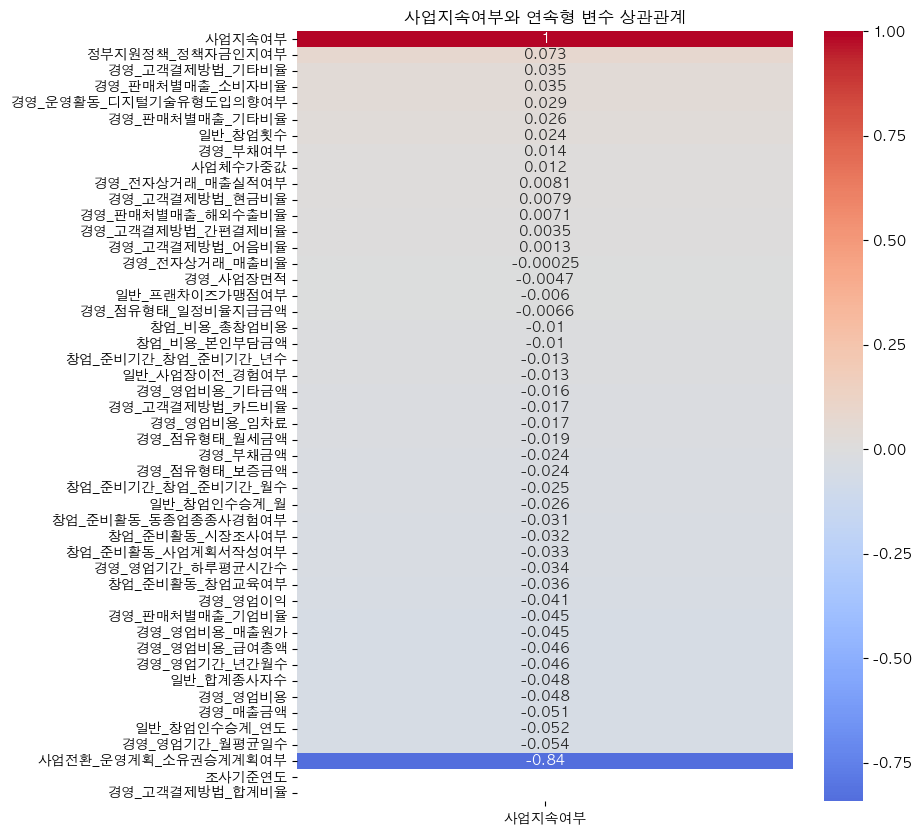

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수만 선택
numeric_df = df.select_dtypes(include=["int64", "float64"])

# 1. 코드 변수 제거
code_cols = [col for col in numeric_df.columns if col.endswith("코드")]

# 2. binary 변수 제거 (단, 사업지속여부는 제외)
binary_cols = [col for col in numeric_df.columns
               if set(df[col].dropna().unique()).issubset({0,1})
               and col != "사업지속여부"]

# 제거할 변수 합치기
drop_cols = set(code_cols + binary_cols)

# 사업지속여부는 절대 제거되지 않도록
drop_cols.discard("사업지속여부")

# 최종 데이터
numeric_clean = numeric_df.drop(columns=drop_cols)

corr_target = numeric_clean.corr()["사업지속여부"].sort_values(ascending=False)

print(corr_target)

plt.figure(figsize=(8,10))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("사업지속여부와 연속형 변수 상관관계")

plt.show()

In [23]:

df = df.drop(columns=[
    "사업전환_운영계획코드",
    "사업전환_운영계획_소유권승계계획여부" #데이터 누수 방지
], errors="ignore")

In [24]:
binary_cols = [col for col in df.columns
               if set(df[col].dropna().unique()).issubset({0,1,0.0,1.0})]

df[binary_cols] = df[binary_cols].astype(int)

In [25]:
cat_cols = [col for col in df.columns if df[col].nunique() < 10]

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


조사기준연도
조사기준연도
2023    40000
Name: count, dtype: int64

일반_대표자_성별코드
일반_대표자_성별코드
1    27330
2    12670
Name: count, dtype: int64

대표자연령대코드
대표자연령대코드
50    16142
60    10518
40     8519
30     2221
70     2115
80      280
20      194
90        6
10        5
Name: count, dtype: int64

일반_무급가족종사자_부부여부
일반_무급가족종사자_부부여부
0    35852
1     4148
Name: count, dtype: int64

일반_무급가족종사자_부모여부
일반_무급가족종사자_부모여부
0    39823
1      177
Name: count, dtype: int64

일반_무급가족종사자_자녀여부
일반_무급가족종사자_자녀여부
0    39657
1      343
Name: count, dtype: int64

일반_무급가족종사자_친인척여부
일반_무급가족종사자_친인척여부
0    39863
1      137
Name: count, dtype: int64

일반_사업자형태코드
일반_사업자형태코드
1    34973
2     5027
Name: count, dtype: int64

일반_프랜차이즈가맹점여부
일반_프랜차이즈가맹점여부
2    38736
1     1264
Name: count, dtype: int64

일반_창업형태코드
일반_창업형태코드
1    35519
2     3574
3      907
Name: count, dtype: int64

일반_사업장이전_경험여부
일반_사업장이전_경험여부
2    34824
1     5176
Name: count, dtype: int64

일반_사업장이전_사유코드
일반_사업장이전_사유코드
0.0    34824
1.0     1884
4.0     1219
3.0      826
2.0    

In [26]:
# 바이너리 변수 매핑 값 0,1 로 재정의
df["경영_부채여부"] = df["경영_부채여부"].map({1:1, 2:0}) # 1:2 로 매핑되어 0, 1 로 yes no 판단 변수

df["경영_점유형태코드"] = df["경영_점유형태코드"].map({
    1: 0,  # 소유
    2: 1   # 임차
})

df = df.rename(columns={ "경영_점유형태코드": "경영_임차여부"})

df = df.drop(columns=["조사기준연도"], errors="ignore") #모두 2023 이어서 제거
df = df.drop(columns=["경영_고객결제방법_합계비율"]) #항상 같은 값인 변수

In [27]:
# 문자열(object) 컬럼 확인
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(obj_cols)

['산업대분류코드', '산업대분류', '산업중분류', '시도']


In [28]:
# 문자열 컬럼 제거
df = df.drop(columns=obj_cols, errors="ignore")

In [29]:
# 해석에 용이하게 변수명 변경
df = df.rename(columns={
    "경영_부채여부": "경영_부채보유여부",
    "경영_전자상거래_매출실적여부": "경영_전자상거래여부",
    "정부지원정책_정책자금인지여부" : "정부지원_정책자금인지여부"
})

In [30]:
# 하나의 변수에서 두 가지 의미를 분리

# 정부지원 신청 여부
df["정부지원_신청여부"] = df["정부지원정책_지원경험코드"].map({
    1: 1,  # 지원받음 → 신청함
    2: 0,  # 신청 안함
    3: 1   # 신청했으나 탈락 → 신청함
})

# 지원 탈락 여부
df["정부지원_탈락여부"] = df["정부지원정책_지원경험코드"].map({
    1: 0,  # 지원받음
    2: 0,  # 신청 안함
    3: 1   # 신청했지만 탈락
})

# 기존 코드 변수 삭제
df = df.drop(columns=["정부지원정책_지원경험코드"])

# 모델링

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, f1_score
import pandas as pd
import numpy as np

# -------------------------------
# 0) 데이터 분리 0.6 : 0.2 : 0.2
# -------------------------------
X = df.drop(columns=["사업지속여부"])
y = df["사업지속여부"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

# -------------------------------
# 1) CV 설정
# -------------------------------
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# -------------------------------
# 2) 핵심 파라미터 4개만 탐색
# -------------------------------
param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

# -------------------------------
# 3) 기본 모델
# -------------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# -------------------------------
# 4) RandomizedSearchCV (F1 기준)
# -------------------------------
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=12,
    scoring="f1",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# -------------------------------
# 5) train 데이터로 탐색
# -------------------------------
random_search.fit(X_train, y_train)

# -------------------------------
# 6) 최적 결과 확인
# -------------------------------
print("Best Params:")
print(random_search.best_params_)

print("\nBest CV F1-score:")
print(random_search.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:
{'n_estimators': 700, 'min_samples_leaf': 10, 'max_depth': None, 'class_weight': 'balanced_subsample'}

Best CV F1-score:
0.21336042058707982


In [32]:
# -------------------------------
# 7) 최적 모델
# -------------------------------
best_rf = random_search.best_estimator_

# -------------------------------
# 8) validation 평가
# -------------------------------
y_val_pred = best_rf.predict(X_val)
y_val_prob = best_rf.predict_proba(X_val)[:, 1]

print("\nValidation F1-score:", f1_score(y_val, y_val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_prob))




Validation F1-score: 0.20959595959595959
Validation ROC-AUC: 0.7662108471257625


In [33]:
from sklearn.metrics import f1_score, recall_score, precision_score

y_prob = best_rf.predict_proba(X_val)[:,1]

for t in [0.5, 0.4, 0.3, 0.2]:
    
    y_pred = (y_prob > t).astype(int)
    
    print("Threshold:", t)
    print("Recall:", recall_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred))
    print("F1:", f1_score(y_val, y_pred))
    print()

Threshold: 0.5
Recall: 0.1704312114989733
Precision: 0.2721311475409836
F1: 0.20959595959595959

Threshold: 0.4
Recall: 0.33880903490759756
Precision: 0.22758620689655173
F1: 0.2722772277227723

Threshold: 0.3
Recall: 0.5338809034907598
Precision: 0.16331658291457288
F1: 0.25012025012025013

Threshold: 0.2
Recall: 0.8028747433264887
Precision: 0.11045197740112994
F1: 0.1941892227464614



In [34]:
# -------------------------------
# 9) test 평가
# -------------------------------
y_test_pred = best_rf.predict(X_test)
y_test_prob = best_rf.predict_proba(X_test)[:,1]

threshold = 0.3
y_test_pred = (y_test_prob > threshold).astype(int)

print("\nTest F1-score:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Test F1-score: 0.270042194092827
Test ROC-AUC: 0.7915123710277955

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      7513
           1       0.17      0.59      0.27       487

    accuracy                           0.81      8000
   macro avg       0.57      0.71      0.58      8000
weighted avg       0.92      0.81      0.85      8000



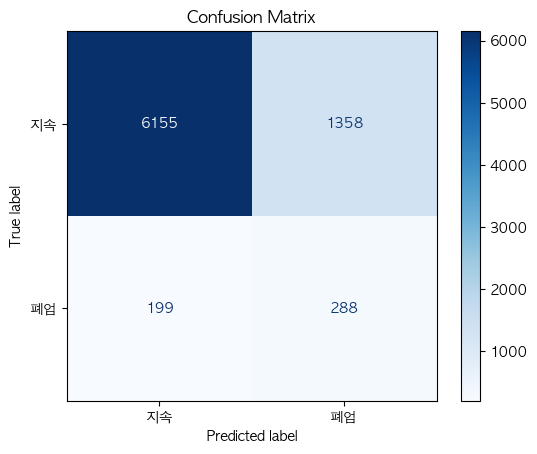

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["지속", "폐업"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# 사후분석

In [36]:
# 변수 중요도 분석
import pandas as pd
import matplotlib.pyplot as plt

# 변수 중요도 추출
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# 상위 20개 출력
print(feature_importance.head(20))

경영_매출금액                   0.048728
경영_영업비용                   0.044508
경영_영업비용_매출원가              0.042373
경영_영업이익                   0.041544
사업체수가중값                   0.032929
경영_영업기간_월평균일수             0.032574
경영_사업장면적                  0.030658
행정구역시도코드                  0.030468
경영_부채금액                   0.029505
경영_영업비용_기타금액              0.027977
일반_창업인수승계_연도              0.027393
산업중분류코드                   0.027302
경영_영업비용_급여총액              0.024257
경영_영업비용_임차료               0.023080
일반_창업인수승계_월               0.021949
경영_운영평가_사업장기비전전략보유정도코드    0.021847
경영_영업기간_하루평균시간수           0.021437
경영_운영평가_신제품신기술적용추진정도코드    0.019703
경영_고객결제방법_현금비율            0.019661
대표자연령대코드                  0.019651
dtype: float64


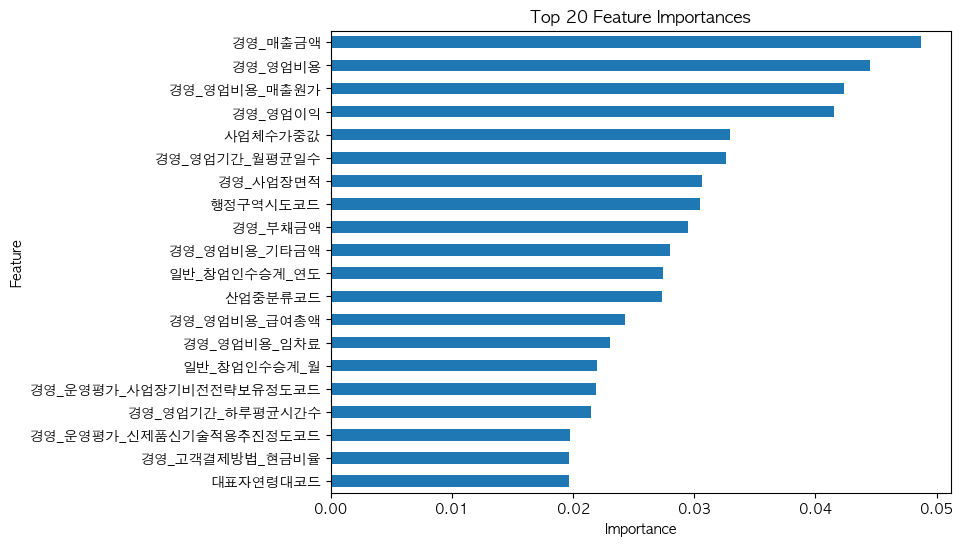

In [37]:
plt.figure(figsize=(8, 6))
feature_importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

class1 shap shape: (500, 117)
연속형 변수 개수: 28
['일반_합계종사자수', '산업중분류코드', '일반_창업인수승계_연도', '일반_창업인수승계_월', '창업_준비기간_창업_준비기간_월수', '창업_비용_총창업비용', '창업_비용_본인부담금액', '경영_영업기간_하루평균시간수', '경영_영업기간_월평균일수', '경영_점유형태_보증금액', '경영_점유형태_월세금액', '경영_사업장면적', '경영_매출금액', '경영_영업비용', '경영_영업비용_매출원가', '경영_영업비용_급여총액', '경영_영업비용_임차료', '경영_영업비용_기타금액', '경영_영업이익', '경영_전자상거래_매출비율', '경영_고객결제방법_현금비율', '경영_고객결제방법_카드비율', '경영_고객결제방법_간편결제비율', '경영_판매처별매출_기업비율', '경영_판매처별매출_소비자비율', '경영_부채금액', '사업체수가중값', '행정구역시도코드']


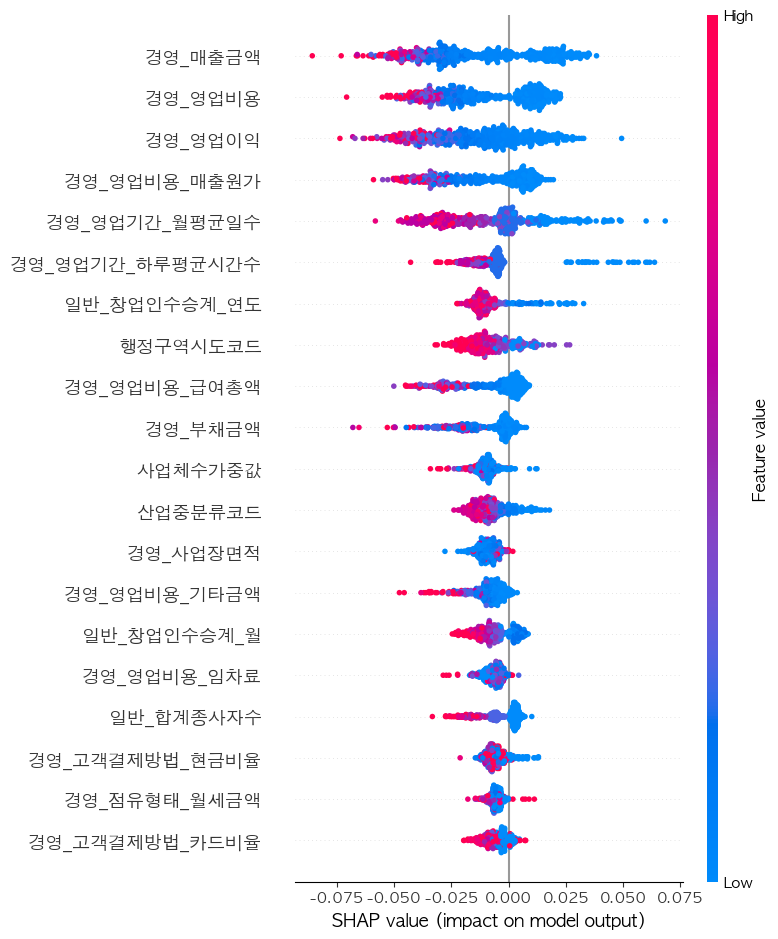

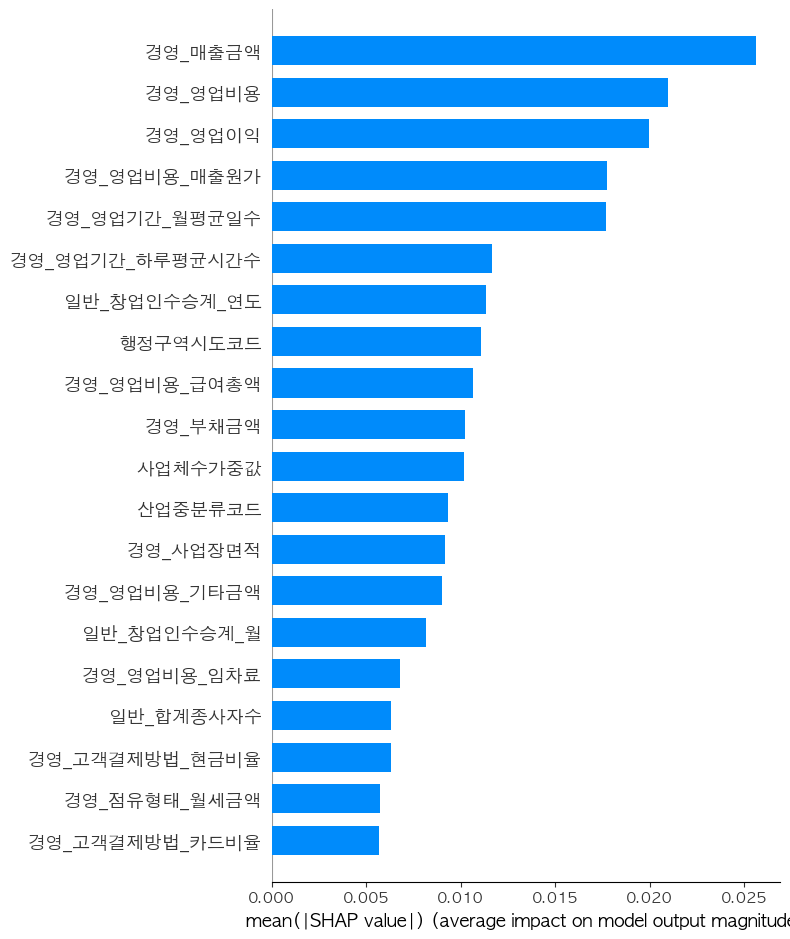

In [39]:
import shap
import numpy as np
import pandas as pd

# 1. 샘플
X_shap_sample = X_test.sample(n=500, random_state=42).copy()

# 2. SHAP 계산
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap_sample)

# 3. class1(폐업) shap 안전하게 추출
if isinstance(shap_values, list):
    shap_values_class1 = np.array(shap_values[1])

else:
    shap_values = np.array(shap_values)

    if shap_values.ndim == 3:
        if shap_values.shape[2] == 2:
            shap_values_class1 = shap_values[:, :, 1]
        elif shap_values.shape[1] == 2:
            shap_values_class1 = shap_values[:, 1, :]
        else:
            raise ValueError(f"예상 못한 3차원 shape: {shap_values.shape}")

    elif shap_values.ndim == 2:
        shap_values_class1 = shap_values
    else:
        raise ValueError(f"예상 못한 shap_values 차원: {shap_values.ndim}")

print("class1 shap shape:", shap_values_class1.shape)

# 4. 연속형 변수만 자동 선택
numeric_cols = X_shap_sample.select_dtypes(include=[np.number]).columns

continuous_cols = [
    col for col in numeric_cols
    if X_shap_sample[col].nunique(dropna=True) > 10
]

print("연속형 변수 개수:", len(continuous_cols))
print(continuous_cols)

# 5. 연속형 변수에 해당하는 shap 값만 자르기
X_num = X_shap_sample[continuous_cols]
col_idx = [X_shap_sample.columns.get_loc(c) for c in continuous_cols]
shap_num = shap_values_class1[:, col_idx]

# 6. plot
shap.summary_plot(shap_num, X_num, max_display=20)
shap.summary_plot(shap_num, X_num, plot_type="bar", max_display=20)

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

image_dir = Path('../images')
image_dir.mkdir(parents=True, exist_ok=True)

# 1. 클래스 불균형 분포
plt.figure(figsize=(6,4))
sns.countplot(x='사업지속여부', data=df)
plt.title('사업지속여부 클래스 분포')
plt.xlabel('사업지속여부 (0=계속 운영, 1=위험 신호)')
plt.ylabel('사업체 수')
plt.tight_layout()
plt.savefig(image_dir / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 산업대분류별 폐업 비율
if '산업대분류' not in df.columns and '산업대분류코드' in df.columns:
    industry_major_map = {
        'C': '제조업', 'F': '건설업', 'G': '도소매업', 'I': '숙박음식점업',
        'J': '정보통신업', 'L': '부동산업', 'M': '전문과학기술업', 'N': '사업시설지원업',
        'P': '교육서비스업', 'R': '예술스포츠여가업', 'S': '수리기타서비스업'
    }
    df['산업대분류'] = df['산업대분류코드'].map(industry_major_map)

industry_exit_rate = df.groupby('산업대분류')['사업지속여부'].mean() * 100
plt.figure(figsize=(8,6))
industry_exit_rate.sort_values().plot(kind='barh')
plt.xlabel('폐업 비율 (%)')
plt.title('산업대분류별 폐업 비율')
plt.tight_layout()
plt.savefig(image_dir / 'industry_exit_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(image_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Feature Importance Top 20
plt.figure(figsize=(8,6))
feature_importance.head(20).sort_values().plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(image_dir / 'feature_importance_top20.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. SHAP Summary Plot
shap.summary_plot(shap_num, X_num, max_display=20, show=False)
plt.tight_layout()
plt.savefig(image_dir / 'shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print('저장 완료:', sorted([p.name for p in image_dir.glob('*.png')]))
